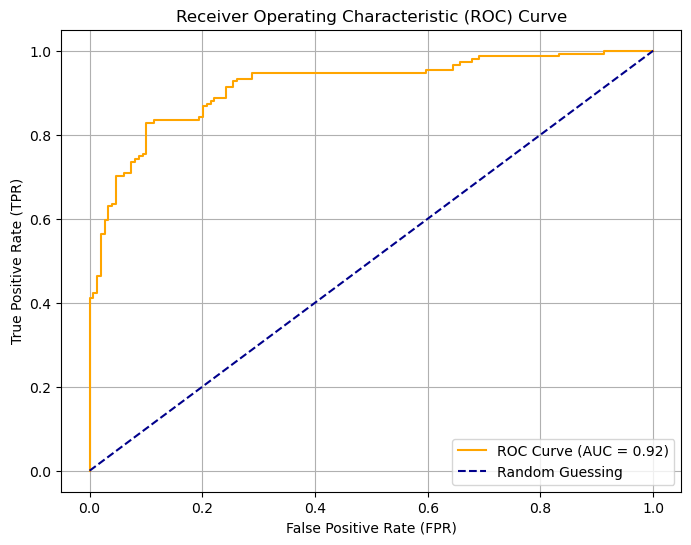

In [1]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# 1. Create a dummy dataset
X, y = make_classification(n_samples=1000, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# 2. Train a model
model = LogisticRegression()
model.fit(X_train, y_train)

# 3. Get predicted probabilities (not the 0/1 labels)
# We take the second column which represents the probability of class '1'
y_probs = model.predict_proba(X_test)[:, 1]

# 4. Calculate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# 5. Calculate AUC Score
auc_value = roc_auc_score(y_test, y_probs)

# 6. Plotting the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--', label='Random Guessing')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()